# peekabook-crs-multisession 결과 분석

wandb 프로젝트 `peekabook-crs-multisession-test1`에서 멀티세션 실험 결과를 불러와
NDCG@3,5,10 / Hit-rate@3,5,10 를 계산

**데이터 구조**:
- `books_detail` Table: `step(session_id), thread_id, rank, title, author, judge_score, judge_reason, self_score, self_reason`
- `sessions_detail` Table: `session_id, preferred_genre, status, self_match_rate, judge_match_rate, verdict, top3_books`
- 스칼라: `match_rate/peekajudge`, `match_rate/peekareader_self`, `verdict_code` (step=session_id)

In [8]:
import math
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import pandas as pd
import wandb

# ── 한글 폰트 설정 ────────────────────────────────────────────────────────
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지

# ── 설정 ─────────────────────────────────────────────────────────────────────
ENTITY        = "jjeong3150-aiffel"
WANDB_PROJECT = f"{ENTITY}/peekabook-crs-multisession-test1"

In [9]:
# ── 지표 계산 함수 ─────────────────────────────────────────────────────────

def dcg_at_k(scores: list, k: int) -> float:
    return sum(r / math.log2(i + 2) for i, r in enumerate(scores[:k]))

def ndcg_at_k(scores: list, k: int) -> float:
    dcg  = dcg_at_k(scores, k)
    idcg = dcg_at_k(sorted(scores, reverse=True), k)
    return round(dcg / idcg, 4) if idcg > 0 else 0.0

def hit_rate_at_k(scores: list, k: int) -> int:
    return 1 if any(s > 0 for s in scores[:k]) else 0

def compute_metrics(ranked_scores: list) -> dict:
    """ranked_scores: rank 오름차순(rank=1부터) 정렬된 0/1 리스트"""
    n = len(ranked_scores)
    return {
        "ndcg@3":        ndcg_at_k(ranked_scores, 3),
        "ndcg@5":        ndcg_at_k(ranked_scores, 5),
        "ndcg@10":       ndcg_at_k(ranked_scores, 10),
        "hr@3":          hit_rate_at_k(ranked_scores, 3),
        "hr@5":          hit_rate_at_k(ranked_scores, 5),
        "hr@10":         hit_rate_at_k(ranked_scores, 10),
        "mean_score@3":  round(sum(ranked_scores[:3])  / 3,  4) if n >= 3  else 0.0,
        "mean_score@5":  round(sum(ranked_scores[:5])  / 5,  4) if n >= 5  else 0.0,
        "mean_score@10": round(sum(ranked_scores[:10]) / 10, 4) if n >= 10 else 0.0,
    }

In [10]:
# ── wandb 런 로드 & books_detail Table 수집 ────────────────────────────────
#
# wandb.log({"books_detail": wandb.Table(...)}) 로 기록된 Table은
# run artifact로 저장됨: type="run_table", name="run-{run_id}-books_detail"

api  = wandb.Api()
runs = api.runs(WANDB_PROJECT)

books_rows    = []   # books_detail 전체
sessions_rows = []   # sessions_detail 전체
run_meta      = []   # run config 메타

for run in runs:
    cfg = run.config
    meta = {
        "run_id":          run.id,
        "run_name":        run.name,
        "persona_name":    cfg.get("persona_name", ""),
        "query_transform": cfg.get("query_transform", ""),
        "use_genre_filter":cfg.get("use_genre_filter", ""),
        "n_sessions":      cfg.get("n_sessions", ""),
        "llm_model":       cfg.get("llm_model", ""),
        "judge_model":     cfg.get("judge_model", ""),
    }
    run_meta.append(meta)

    for artifact in run.logged_artifacts():
        if artifact.type != "run_table":
            continue

        # artifact name 예: "run-abc123-books_detail:v0"
        table_name = artifact.name.split("-", 2)[-1].split(":")[0]  # "books_detail"

        if table_name == "books_detail":
            artifact.download()  # 캐시에 다운로드
            table = artifact.get("books_detail")
            if table is None:
                continue
            for row in table.data:
                books_rows.append({**meta, **dict(zip(table.columns, row))})

        elif table_name == "sessions_detail":
            artifact.download()
            table = artifact.get("sessions_detail")
            if table is None:
                continue
            for row in table.data:
                sessions_rows.append({**meta, **dict(zip(table.columns, row))})

df_books    = pd.DataFrame(books_rows)
df_sessions = pd.DataFrame(sessions_rows)

print(f"books_detail 행: {len(df_books)}")
print(f"sessions_detail 행: {len(df_sessions)}")
df_books.head()

wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  
wandb:   1 of 1 files downloaded.  


books_detail 행: 150
sessions_detail 행: 15


,run_id,run_name,persona_name,query_transform,use_genre_filter,n_sessions,llm_model,judge_model,step,thread_id,rank,title,author,judge_score,judge_reason,self_score,self_reason
0,fy60wnig,restful-sweep-1,A_최재원,none,,,,,1,sim_A_최재원_s1_1781706015,1,부자 아빠 가난한 아빠 2,[로버트 기요사키],0,"사용자가 '다들 읽는 뻔한 베스트셀러'를 싫어하는데, 이 책은 전 세계적 열풍의 속...",1,이직 준비 중 재정 상황을 점검하고 경제적 기반을 다지기 위한 실용적인 조언을 제공...
1,fy60wnig,restful-sweep-1,A_최재원,none,,,,,1,sim_A_최재원_s1_1781706015,2,"주식회사 대한민국, 이제 다시 시작이다",[삼정KPMG 경제연구원],0,"글로벌 경제 위기 진단과 거시경제 방향성을 다루는 책으로, 이직 준비 중 개인의 재...",0,"경제위기와 관련된 내용이지만, 현재 상황에 적합한 실질적인 재정 전략보다는 진단과 ..."
2,fy60wnig,restful-sweep-1,A_최재원,none,,,,,1,sim_A_최재원_s1_1781706015,3,똑똑한 금융생활 - 건전한 투자와 건강한 재무설계 지침서,[박덕배],1,금융 기초부터 핵심까지 체계적으로 정리한 실용서로 reading_goal(경제적 기...,1,핵심적인 금융 지식과 실생활에 적용 가능한 내용을 제공하여 재정적 어려움을 극복하는...
3,fy60wnig,restful-sweep-1,A_최재원,none,,,,,1,sim_A_최재원_s1_1781706015,4,따라하는 재테크 - 돈 좀 모아볼까?,[김경환],1,Check list와 To do list로 '따라하면' 실천할 수 있는 구체적 가이...,1,실천 가능한 재테크 방법과 체크리스트를 제공하여 이직 준비 중 재정 관리에 유용할 ...
4,fy60wnig,restful-sweep-1,A_최재원,none,,,,,1,sim_A_최재원_s1_1781706015,5,돈의 인문학 - 지금 우리에게 필요한 돈과 경제에 대한 통찰,[홍익희],0,"경제사적 반추, 사회학적 조망, 경제 이론 분석 등 인문학적·학술적 접근으로 dif...",0,경제 이론과 분석이 주를 이루어 실생활에 직접적으로 연결되기 어려울 수 있습니다.


In [11]:
# ── 세션별 NDCG / Hit-rate 계산 ────────────────────────────────────────────
#
# books_detail의 rank 열 기준으로 오름차순 정렬 후 judge_score 리스트를 생성

metric_rows = []

group_cols = ["run_id", "persona_name", "query_transform", "use_genre_filter", "step"]

for key, grp in df_books.groupby(group_cols):
    grp_sorted     = grp.sort_values("rank")
    judge_scores   = grp_sorted["judge_score"].tolist()
    self_scores    = grp_sorted["self_score"].tolist()

    judge_metrics  = compute_metrics(judge_scores)
    self_metrics   = {f"self_{k}": v for k, v in compute_metrics(self_scores).items()}

    row = dict(zip(group_cols, key if isinstance(key, tuple) else (key,)))
    row["session_id"]   = row.pop("step")
    row["n_books"]      = len(grp_sorted)
    row.update(judge_metrics)
    row.update(self_metrics)
    metric_rows.append(row)

df_metrics = pd.DataFrame(metric_rows)
print(f"세션별 메트릭: {len(df_metrics)}행")
df_metrics.head(10)

세션별 메트릭: 15행


,run_id,persona_name,query_transform,use_genre_filter,session_id,n_books,ndcg@3,ndcg@5,ndcg@10,hr@3,hr@5,hr@10,mean_score@3,mean_score@5,mean_score@10,self_ndcg@3,self_ndcg@5,self_ndcg@10,self_hr@3,self_hr@5,self_hr@10,self_mean_score@3,self_mean_score@5,self_mean_score@10
0,fy60wnig,A_최재원,none,,1,10,0.2346,0.4367,0.5932,1,1,1,0.3333,0.4000,0.3000,0.7039,0.9060,0.9060,1,1,1,0.6667,0.6000,0.3000
1,fy60wnig,A_최재원,none,,2,10,0.2961,0.3601,0.6900,1,1,1,0.3333,0.4000,0.5000,0.7654,0.8304,0.9430,1,1,1,0.6667,0.8000,0.8000
2,fy60wnig,A_최재원,none,,3,10,0.6131,0.8503,0.8503,1,1,1,0.3333,0.4000,0.2000,0.7654,0.7877,0.9005,1,1,1,0.6667,0.6000,0.4000
3,h63o8myo,D_이수빈,none,,1,10,0.0000,0.4307,0.4307,0,1,1,0.0000,0.2000,0.1000,1.0000,0.8319,0.9620,1,1,1,1.0000,0.6000,0.4000
4,h63o8myo,D_이수빈,none,,2,10,0.0000,0.4307,0.4307,0,1,1,0.0000,0.2000,0.1000,0.2961,0.6797,0.6797,1,1,1,0.3333,0.6000,0.3000
5,h63o8myo,D_이수빈,none,,3,10,0.0000,0.0000,0.3010,0,0,1,0.0000,0.0000,0.1000,0.0000,0.0000,0.3010,0,0,1,0.0000,0.0000,0.1000
6,kfg8cg4k,B_한미영,none,,1,10,0.0000,0.3869,0.3869,0,1,1,0.0000,0.2000,0.1000,0.6131,0.8503,0.8503,1,1,1,0.3333,0.4000,0.2000
7,kfg8cg4k,B_한미영,none,,2,10,0.6131,0.6131,0.7977,1,1,1,0.3333,0.2000,0.2000,0.0000,0.0000,0.4649,0,0,1,0.0000,0.0000,0.3000
8,kfg8cg4k,B_한미영,none,,3,10,1.0000,0.8688,0.9818,1,1,1,1.0000,0.8000,0.5000,1.0000,1.0000,1.0000,1,1,1,1.0000,1.0000,0.9000
9,r52q7gwj,E_정미희,none,,1,10,0.0000,0.0000,0.3562,0,0,1,0.0000,0.0000,0.1000,0.3066,0.3066,0.5250,1,1,1,0.3333,0.2000,0.2000


In [12]:
# ── 페르소나 × query_transform 집계 ───────────────────────────────────────

metric_cols = ["ndcg@3", "ndcg@5", "ndcg@10", "hr@3", "hr@5", "hr@10",
               "mean_score@3", "mean_score@5", "mean_score@10"]

summary = (
    df_metrics
    .groupby(["persona_name", "query_transform", "use_genre_filter"])[metric_cols]
    .mean()
    .round(4)
    .reset_index()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
summary

,persona_name,query_transform,use_genre_filter,ndcg@3,ndcg@5,ndcg@10,hr@3,hr@5,hr@10,mean_score@3,mean_score@5,mean_score@10
0,A_최재원,none,,0.3813,0.5490,0.7112,1.0000,1.0000,1.0000,0.3333,0.4000,0.3333
1,B_한미영,none,,0.5377,0.6229,0.7221,0.6667,1.0000,1.0000,0.4444,0.4000,0.2667
2,C_오민아,none,,0.5000,0.5000,0.5964,0.6667,0.6667,1.0000,0.2222,0.1333,0.1000
3,D_이수빈,none,,0.0000,0.2871,0.3875,0.0000,0.6667,1.0000,0.0000,0.1333,0.1000
4,E_정미희,none,,0.2044,0.2044,0.3822,0.3333,0.3333,0.6667,0.1111,0.0667,0.1000


── 페르소나별 세션별 ndcg@3 ──


session_id,1,2,3
persona_name,,,
A_최재원,0.2346,0.2961,0.6131
B_한미영,0.0000,0.6131,1.0000
C_오민아,0.5000,0.0000,1.0000
D_이수빈,0.0000,0.0000,0.0000
E_정미희,0.0000,0.0000,0.6131


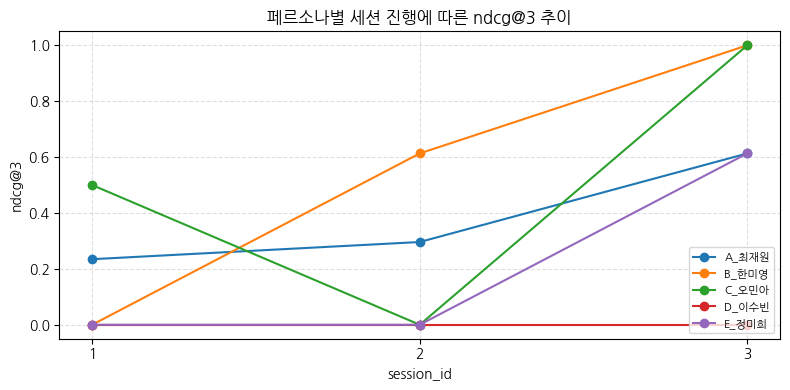

In [13]:
# ── 페르소나별 세션(step)별 NDCG 추이 ─────────────────────────────────────

NDCG_COL = "ndcg@3"   # 바꾸면 다른 지표로 전환

# 페르소나 × 세션 평균 (런이 여러 개면 평균)
pivot = (
    df_metrics
    .groupby(["persona_name", "session_id"])[NDCG_COL]
    .mean()
    .round(4)
    .unstack("session_id")
)
print("── 페르소나별 세션별", NDCG_COL, "──")
display(pivot)

# ── 그래프 ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

for persona, row in pivot.iterrows():
    ax.plot(row.index.tolist(), row.values.tolist(), marker="o", label=persona)

ax.set_title(f"페르소나별 세션 진행에 따른 {NDCG_COL} 추이")
ax.set_xlabel("session_id")
ax.set_ylabel(NDCG_COL)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(loc="lower right", fontsize=8)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [14]:
# ── sessions_detail 기반 verdict 분포 ─────────────────────────────────────

if not df_sessions.empty:
    print(df_sessions["verdict"].value_counts())
    df_sessions[["persona_name", "session_id", "preferred_genre",
                 "status", "self_match_rate", "judge_match_rate", "verdict"]].head(20)

verdict
genre_mismatch    11
unsatisfied        2
satisfied          2
Name: count, dtype: int64


In [15]:
# ── 책 단위 상세: judge_score=0 케이스 분석 ───────────────────────────────

miss = df_books[df_books["judge_score"] == 0][["persona_name", "step", "rank", "title", "author", "judge_reason"]]
miss.sort_values(["persona_name", "step", "rank"]).head(20)

,persona_name,step,rank,title,author,judge_reason
0,A_최재원,1,1,부자 아빠 가난한 아빠 2,[로버트 기요사키],"사용자가 '다들 읽는 뻔한 베스트셀러'를 싫어하는데, 이 책은 전 세계적 열풍의 속..."
1,A_최재원,1,2,"주식회사 대한민국, 이제 다시 시작이다",[삼정KPMG 경제연구원],"글로벌 경제 위기 진단과 거시경제 방향성을 다루는 책으로, 이직 준비 중 개인의 재..."
4,A_최재원,1,5,돈의 인문학 - 지금 우리에게 필요한 돈과 경제에 대한 통찰,[홍익희],"경제사적 반추, 사회학적 조망, 경제 이론 분석 등 인문학적·학술적 접근으로 dif..."
5,A_최재원,1,6,걸어다니는 경제사,[황세연],"경제사를 역사 순서에 따라 설명하는 기초 경제 입문서로, 경제정책 변화와 위기 극복..."
7,A_최재원,1,8,"경제학, 현실에 말을 걸다 - 더 나은 내일을 위한 통섭",[이면희],"경제학 전공자가 아닌 사람을 위한 참고서이지만, 화폐제도·실물경제·금융위기 등 거시..."
8,A_최재원,1,9,"내 삶을 바꾼 인생역전 독서법 - 저는 이 독서법으로 구독자 15만, 연봉 2억이 ...",[이상윤],"독서를 통한 성공 스토리와 독서법 자체가 주제로, preferred_genre(경제..."
9,A_최재원,1,10,파산수업 - 무너진 우리를 다시 세우는 문학의 힘,[정재엽],"회사 부도와 정신적 파산 극복 과정에서 문학 읽기의 위로와 회복을 다루는 책으로, ..."
10,A_최재원,2,1,철학9단의 힐링노트 - 삶의 열정과 지혜와 행복을 주는,[이창호],"소개글에서 '자기계발서와는 질적으로 다르다'고 강조하지만, 실제로는 '힘과 용기와 ..."
12,A_최재원,2,3,별난 가르침 4 - 가름침은 사랑이다,[김춘현],주 대상이 '공부에 지친 아이들과 부모님'으로 설정되어 있어 32세 직장인의 cur...
14,A_최재원,2,5,사랑하라 다시 한번 더,[김지연],주제가 연애와 사랑 극복에 집중되어 있어 '경제 공부로 지친 마음을 달래줄 책'이라...
